# Импорт библиотек

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

# Загрузка дата сета

In [2]:
dataset = pd.read_csv("Data/S02-hw-dataset.csv")

# Первичный осмотр

In [3]:
dataset.head(5)

,user_id,age,country,purchases,revenue
0,1,25.0,FR,7,749
1,2,24.0,RU,5,1115
2,3,52.0,FR,7,399
3,4,31.0,RU,6,654
4,5,NaN,DE,6,1296


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB


In [5]:
dataset.describe()

,user_id,age,purchases,revenue
count,41.000000,39.000000,41.000000,41.000000
mean,20.243902,36.512821,4.829268,820.048780
std,11.659289,18.304259,2.710189,613.127269
min,1.000000,5.000000,-1.000000,0.000000
25%,10.000000,24.000000,3.000000,432.000000
50%,20.000000,33.000000,5.000000,693.000000
75%,30.000000,45.500000,7.000000,1115.000000
max,40.000000,120.000000,11.000000,2475.000000


In [6]:
dataset.columns

Index(['user_id', 'age', 'country', 'purchases', 'revenue'], dtype='object')

# Пропуски, дубликаты и базовый контроль качества

In [7]:
dataset.isna().mean() 

user_id      0.00000
age          0.04878
country      0.00000
purchases    0.00000
revenue      0.00000
dtype: float64

Значит пропуски есть только в колонке age

In [8]:
duplicates = dataset[dataset.duplicated(keep=False)]
print(f"Найдено дубликатов: {dataset.duplicated().sum()}")
print(duplicates)

Найдено дубликатов: 1
    user_id   age country  purchases  revenue
9        10  24.0      RU          7      511
40       10  24.0      RU          7      511


Строки 9 и 40 являются полными дубликатами

In [9]:
dataset['age'].describe()

count     39.000000
mean      36.512821
std       18.304259
min        5.000000
25%       24.000000
50%       33.000000
75%       45.500000
max      120.000000
Name: age, dtype: float64

При среднем возрасте $\approx$ 36, минимум в виде 5 и максимум в 120 кажутся подозрительными

In [10]:
dataset['purchases'].describe()

count    41.000000
mean      4.829268
std       2.710189
min      -1.000000
25%       3.000000
50%       5.000000
75%       7.000000
max      11.000000
Name: purchases, dtype: float64

Отрицательная покупка, так же выглядит подозрительно, но возможно так маркируется возрат, как говорится записали карандашиком

In [11]:
dataset['revenue'].describe()

count      41.000000
mean      820.048780
std       613.127269
min         0.000000
25%       432.000000
50%       693.000000
75%      1115.000000
max      2475.000000
Name: revenue, dtype: float64

Нулевая доходность, сомнительно, добавим в список карандашиком

Посмотрим внимательнее на все эти странные данные

In [12]:
suspicious_age = dataset[(dataset['age'] == 5) | (dataset['age'] == 120)]
print(suspicious_age)

    user_id    age country  purchases  revenue
5         6  120.0      FR         -1      785
20       21    5.0      RU          8     1488


И так у нас есть французский пожилой человек, который что то вернул, возможно, и мы на этом заработали  
А ещё у нас есть русский ребенок 5 лет который купил 8 раз, с общей нашей доходностью $\approx$ 1500  
Эти данные явно странные

In [13]:
 missing_age_rows = dataset[dataset['age'].isna()]
 print(missing_age_rows)

    user_id  age country  purchases  revenue
4         5  NaN      DE          6     1296
12       13  NaN      US          9      630


Отсутсвие данных о возрасте не делает эти данные сразу плохими или подозрительными

In [14]:
suspicious_revenue = dataset[(dataset['revenue'] == 0)]
print(suspicious_revenue)

    user_id   age country  purchases  revenue
6         7  46.0      RU          0        0
10       11  24.0      US          4        0
17       18  24.0      RU          0        0
33       34  28.0      FR          0        0


Логично что когда человек не купил ничего мы ничего не заработали, но когда человек сделал 4 покупки, а мы ничего не заработали, это уже вызывает подозрения

# Краткий вывод  
Подозрительные строки:  
5 - Слишком сильно отличается возраст, покупка равна -1, и при этом в дозодности сказано что мы что то заработали  
20 - 5 летний ребенок с 8 покупками  
4 - отсутсвие информации о возрасте  
12 - отсутсвие информации о возрасте  
10 - 4 покупки и нулевой доход  
40 - полный дубликат 9 строки  
Итого 6 строк являются  подозрительными

# Базовый EDA: группировки, агрегаты и частоты

In [15]:
dataset_clean = dataset.drop_duplicates().reset_index(drop=True)

Убрали дубликат

In [16]:
country_freq = dataset_clean['country'].value_counts()
print(country_freq)

country
FR    12
RU    12
US     8
DE     6
CN     2
Name: count, dtype: int64


Проверим частоты по странам

In [17]:
group_stats = dataset_clean.groupby('country').agg(
    avg_purchases=('purchases', 'mean'),
    total_purchases=('purchases', 'sum'),
    avg_revenue=('revenue', 'mean'),
    total_revenue=('revenue', 'sum'),
    user_count=('user_id', 'count')
).round(2)

print(group_stats)

         avg_purchases  total_purchases  avg_revenue  total_revenue  \
country                                                               
CN                4.50                9      1054.00           2108   
DE                6.50               39      1445.50           8673   
FR                4.25               51       675.92           8111   
RU                4.58               55       813.33           9760   
US                4.62               37       557.38           4459   

         user_count  
country              
CN                2  
DE                6  
FR               12  
RU               12  
US                8  


Из данной статистики видно что:   
Количество покупок одним пользователем больше всего в Германии  
При этом больше всего покупок в России  
Самые большик покупки в среднем делают Немцы  
Но покупают больше всего в России  
Так же можно сказать что при подобном среднем количестве купленных товаров одним человеком (RU и US) итоговая доходность US ниже в 2 раза

In [18]:
valid_age = dataset_clean[(dataset_clean['age'] >= 18) & (dataset_clean['age'] <= 100)]

# Создаём возрастные группы
bins = [17, 25, 35, 50, 100]
labels = ['18–25', '26–35', '36–50', '51+']
valid_age = valid_age.copy()
valid_age['age_group'] = pd.cut(valid_age['age'], bins=bins, labels=labels)

# Агрегация по возрастным группам
age_group_stats = valid_age.groupby('age_group', observed=True).agg(
    avg_revenue=('revenue', 'mean'),
    total_revenue=('revenue', 'sum'),
    user_count=('user_id', 'count')
).round(2)

print(age_group_stats)

           avg_revenue  total_revenue  user_count
age_group                                        
18–25           640.90           6409          10
26–35           946.82          10415          11
36–50           945.33           8508           9
51+             596.67           3580           6


Сделали группировку по возрастам из чего можно сделать следующие вывода:  
Группа 26 - 35 лет имеет: наибольший средний чек, максимальную сумму доходности и максимальное число клиентов  
Группа 36 - 50 лет занимает 2 место по среднему чеку, итоговой доходности, при этом занимая 3 место по числу пользователей  
Группа 18 - 25 лет имеет: при 2 месте по количеству пользователей сильно отстаёт по среднему чеку и итоговой доходности, при этом видно что итоговая доходность = число пользователей * средний чек, т.е. внутри группы отличия в покупках минимальны

In [19]:
dataset_clean = dataset[
    (dataset['age'].between(18, 100)) & (dataset['purchases'] >= 0)
].copy()

Особый вариант датасета откуда мы убрали все подозрительные записи

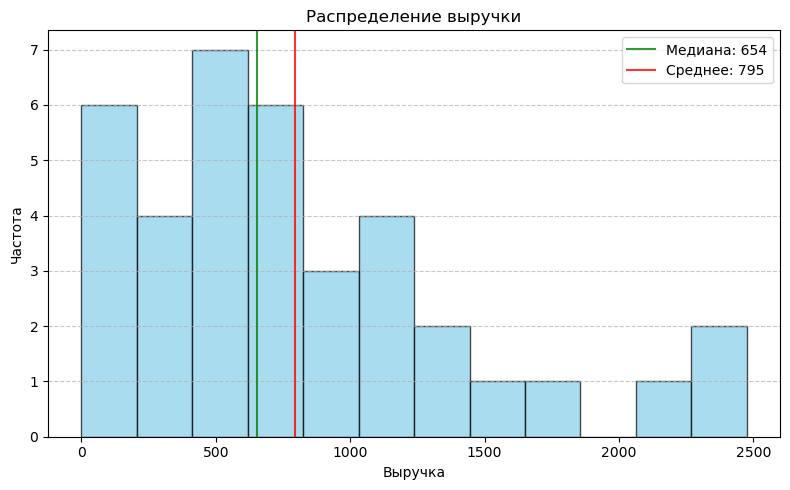

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(dataset_clean['revenue'], bins=12, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Распределение выручки')
plt.xlabel('Выручка')
plt.ylabel('Частота')

revenue_median = dataset_clean['revenue'].median()
revenue_mean = dataset_clean['revenue'].mean()

plt.axvline(revenue_median, color='green', alpha=0.8, label=f'Медиана: {round(revenue_median)}')
plt.axvline(revenue_mean, color='red', alpha=0.8, label=f'Среднее: {round(revenue_mean)}')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend() 
plt.tight_layout()
plt.savefig("figures/histogram_revenue.png")
plt.show()

Из этого графика видно что чаще всего покупка приносит $\approx$ 500 неизвестной валюты выручки

<Figure size 800x500 with 0 Axes>

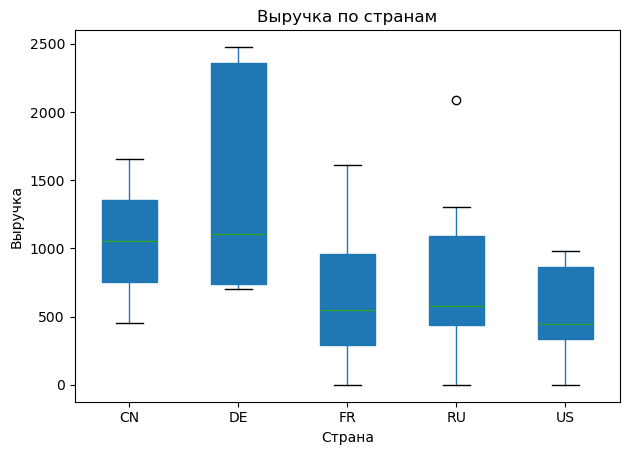

In [21]:
plt.figure(figsize=(8, 5))
dataset_clean.boxplot(column='revenue', by='country', grid=False, patch_artist=True)
plt.title('Выручка по странам')
plt.suptitle('')
plt.xlabel('Страна')
plt.ylabel('Выручка')
plt.tight_layout()
plt.savefig("figures/boxplot_revenue.png")
plt.show()

Из графика видно что самую большую выручки приносит Германия, а Сша приносит наименьшую

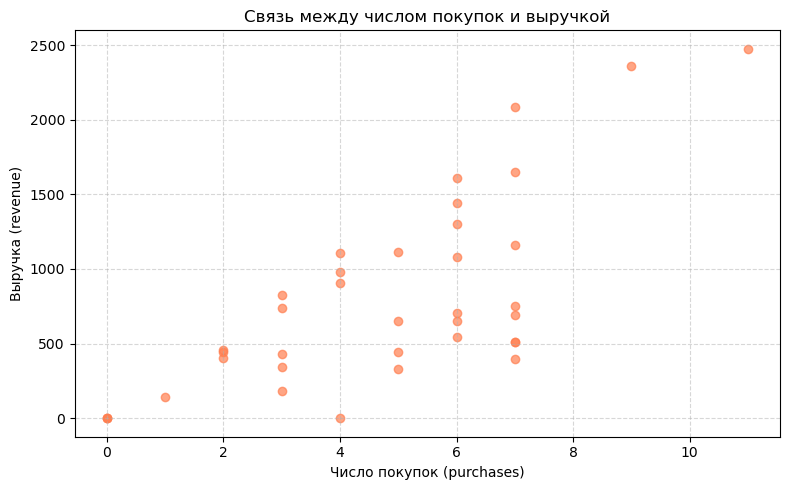

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(dataset_clean['purchases'], dataset_clean['revenue'], alpha=0.7, color='coral')
plt.title('Связь между числом покупок и выручкой')
plt.xlabel('Число покупок (purchases)')
plt.ylabel('Выручка (revenue)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("figures/scatter_revenue.png")
plt.show()

Из графика видно что что чем больше число покупок, тем выше выручка